In [1]:
%matplotlib widget

In [2]:
import math
import random
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
from typing import List, Tuple, Union
from dataclasses import dataclass
from scipy.spatial import distance
from scipy.linalg import block_diag
from numpy import dot
from numpy.linalg import norm

In [3]:
import os
import sys

sys.path.append('/home/morita/src/3D_Estimation/src')

from plot import *
from calculate import *
from optimization import *

## 線源と検出器の座標系

### 線源
空間 10 * 10 * 10 [m] \
線源位置 [4.0,4.0,0.0], 100 Gy\
線源位置 [7.0,3.0,10.0], 200 Gy\
線源位置 [7.0,10,8.0], 150 Gy\

### 検出器
高さ 0.5 [m]

### 遮蔽
鉛 \
1/10に減衰

In [4]:
# 線源
source_1 = [8.5, 3.5, 0.0,100]
source_2 = [7.0,3.0,10.0,200]
source_3 = [7.0,10,5.0,150]
source_list = []
source_list.append(source_1)
source_list.append(source_2)
source_list.append(source_3)

In [5]:
# 部屋
x = 10
y = 10
z = 10

In [6]:
g = 1
q_max = 200
q_init = 1/q_max
q1 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 地面 z=0
q2 = np.array([q_init] * (x * y)).reshape(x * y, 1)  # 天井 z=10
q3 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面1 x=0
q4 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面2 y=0
q5 = np.array([q_init] * (y * z)).reshape(y * z, 1)  # 側面3 x=10
q6 = np.array([q_init] * (x * z)).reshape(x * z, 1)  # 側面4 y=10

In [7]:
def decide_measurement_points(x,y,r):
    m_p = []
    #z軸は固定
    m_p_c = []
    for i in range(x):
        for j in range(y):
            m_p_c.append([0.5+i,0.5+j,0.5])
    
    num_points = int(r * len(m_p_c))
    m_p = random.sample(m_p_c, num_points)
    return m_p

In [8]:
r = 0.3
m_p = decide_measurement_points(x,y,r)

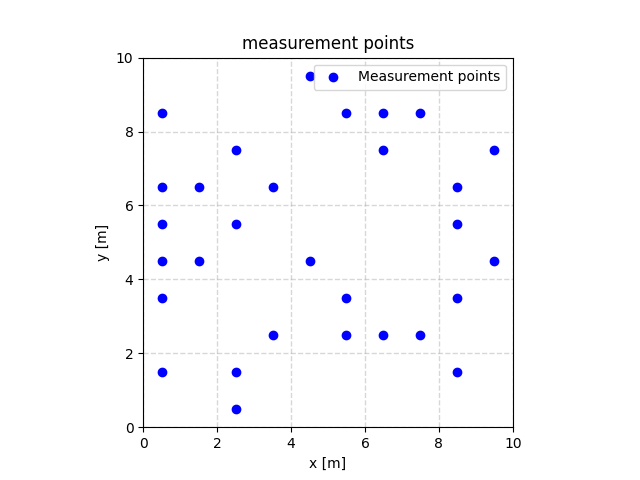

In [9]:
plot_measurement_points(m_p, source_list, "measurement points", x, y)

In [10]:
# 角度の8通りのシールド向きリスト
shield_orientations = [
    {'theta': (0, np.pi / 2), 'phi': (0, np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi / 2, np.pi)},
    {'theta': (0, np.pi / 2), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (0, np.pi / 2), 'phi': (3 * np.pi / 2, 2 * np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (0, np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi / 2, np.pi)},
    {'theta': (np.pi / 2, np.pi), 'phi': (np.pi, 3 * np.pi / 2)},
    {'theta': (np.pi / 2, np.pi), 'phi': (3 * np.pi / 2, 2 * np.pi)}
]


In [11]:
b_m = measurement_shield(m_p, source_list, shield_orientations)
print(len(b_m))
print(b_m)

240
[5.003766133070457, 8.014582726437864, 8.014582726437864, 6.4490455580638155, 8.014582726437864, 8.014582726437864, 8.014582726437864, 5.392022287446302, 3.808429758088547, 5.4769627928029925, 5.4769627928029925, 4.013456560045991, 5.4769627928029925, 5.4769627928029925, 5.4769627928029925, 3.689446473689341, 27.223343163122767, 23.905354428303628, 27.223343163122767, 27.223343163122767, 6.088591390073123, 6.088591390073123, 27.223343163122767, 27.223343163122767, 1.7295470486959852, 4.062604062604063, 4.062604062604063, 4.062604062604063, 2.746520618861044, 4.062604062604063, 4.062604062604063, 4.062604062604063, 3.2087486344941922, 4.494992477484088, 4.494992477484088, 3.1417315353302495, 3.0969738777103757, 4.494992477484088, 4.494992477484088, 4.494992477484088, 19.47081725299834, 23.205873191067152, 23.205873191067152, 23.205873191067152, 6.096788422407914, 23.205873191067152, 23.205873191067152, 23.205873191067152, 10.16940769969723, 13.817193697543445, 13.817193697543445, 13

In [12]:
# 例: グリッド生成時に g の値を指定（省略可）
ground_grid = create_grid('z', 0, g=1)    # 地面 z=0
ceiling_grid = create_grid('z', 10, g=1)  # 天井 z=10
side1_grid = create_grid('x', 0, g=1)     # 側面1 x=0
side2_grid = create_grid('y', 0, g=1)     # 側面2 y=0
side3_grid = create_grid('x', 10, g=1)    # 側面3 x=10
side4_grid = create_grid('y', 10, g=1)    # 側面4 y=10


# 結果をリストとして保存
all_grids = {
    "ground": ground_grid,
    "ceiling": ceiling_grid,
    "side1": side1_grid,
    "side2": side2_grid,
    "side3": side3_grid,
    "side4": side4_grid
}

# 各面のグリッドを出力
for surface, grid in all_grids.items():
    print(f"{surface} grid:")
    print(grid)
    print()


ground grid:
[[0.5, 0.5, 0], [1.5, 0.5, 0], [2.5, 0.5, 0], [3.5, 0.5, 0], [4.5, 0.5, 0], [5.5, 0.5, 0], [6.5, 0.5, 0], [7.5, 0.5, 0], [8.5, 0.5, 0], [9.5, 0.5, 0], [0.5, 1.5, 0], [1.5, 1.5, 0], [2.5, 1.5, 0], [3.5, 1.5, 0], [4.5, 1.5, 0], [5.5, 1.5, 0], [6.5, 1.5, 0], [7.5, 1.5, 0], [8.5, 1.5, 0], [9.5, 1.5, 0], [0.5, 2.5, 0], [1.5, 2.5, 0], [2.5, 2.5, 0], [3.5, 2.5, 0], [4.5, 2.5, 0], [5.5, 2.5, 0], [6.5, 2.5, 0], [7.5, 2.5, 0], [8.5, 2.5, 0], [9.5, 2.5, 0], [0.5, 3.5, 0], [1.5, 3.5, 0], [2.5, 3.5, 0], [3.5, 3.5, 0], [4.5, 3.5, 0], [5.5, 3.5, 0], [6.5, 3.5, 0], [7.5, 3.5, 0], [8.5, 3.5, 0], [9.5, 3.5, 0], [0.5, 4.5, 0], [1.5, 4.5, 0], [2.5, 4.5, 0], [3.5, 4.5, 0], [4.5, 4.5, 0], [5.5, 4.5, 0], [6.5, 4.5, 0], [7.5, 4.5, 0], [8.5, 4.5, 0], [9.5, 4.5, 0], [0.5, 5.5, 0], [1.5, 5.5, 0], [2.5, 5.5, 0], [3.5, 5.5, 0], [4.5, 5.5, 0], [5.5, 5.5, 0], [6.5, 5.5, 0], [7.5, 5.5, 0], [8.5, 5.5, 0], [9.5, 5.5, 0], [0.5, 6.5, 0], [1.5, 6.5, 0], [2.5, 6.5, 0], [3.5, 6.5, 0], [4.5, 6.5, 0], [5.5, 6.5, 

In [13]:
# 各面のA行列の作成
A1 = create_A(10, 10, m_p, ground_grid, shield_orientations)  # 地面 z=0
A2 = create_A(10, 10, m_p, ceiling_grid, shield_orientations) # 天井 z=10
A3 = create_A(10, 10, m_p, side1_grid, shield_orientations)   # 側面1 x=0
A4= create_A(10, 10, m_p, side2_grid, shield_orientations)   # 側面2 y=0
A5= create_A(10, 10, m_p, side3_grid, shield_orientations)   # 側面3 x=10
A6 = create_A(10, 10, m_p, side4_grid, shield_orientations)   # 側面4 y=10

In [14]:
# 全体のA行列を結合
A = np.hstack((A1, A2, A3, A4, A5, A6))

print("Final A matrix:")
print(f"A: {A.shape}")

Final A matrix:
A: (240, 600)


In [15]:
q = np.vstack((q1, q2, q3, q4, q5, q6))
print(f"q: {q.shape}")
b = np.dot(A,q)
print(len(b))

q: (600, 1)
240


In [16]:
b_m_s = np.array(b_m)

In [17]:
init_score = score_func(A, b_m_s, q)
print(f'Initial score: {init_score}')

Initial score: -2903939.5515522636


In [18]:
q_optimized = Adam(A, b_m_s, q, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8, max_iter=100000)

In [19]:

final_score = score_func(A, b_m_s, q_optimized)
print(f'Final score: {final_score}')


Final score: 2965255.0895929905


In [20]:
q_shapes = [
    (x * y, 1),  # 地面 z=0 に対応
    (x * y, 1),  # 天井 z=10 に対応
    (y * z, 1),  # 側面1 x=0 に対応
    (x * z, 1),  # 側面2 y=0 に対応
    (y * z, 1),  # 側面3 x=10 に対応
    (x * z, 1)   # 側面4 y=10 に対応
]
restored_qs = restore_q(q_optimized, q_shapes)

In [21]:
# 各qの最大値と最小値を求める
all_q_values = np.concatenate([q.flatten() for q in restored_qs])
vmin, vmax = all_q_values.min(), all_q_values.max()

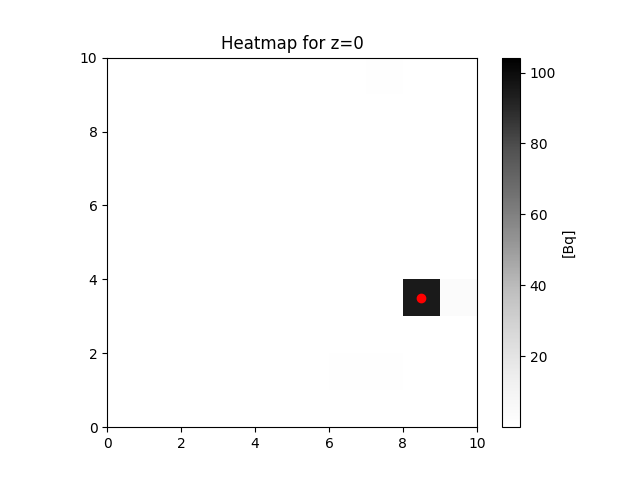

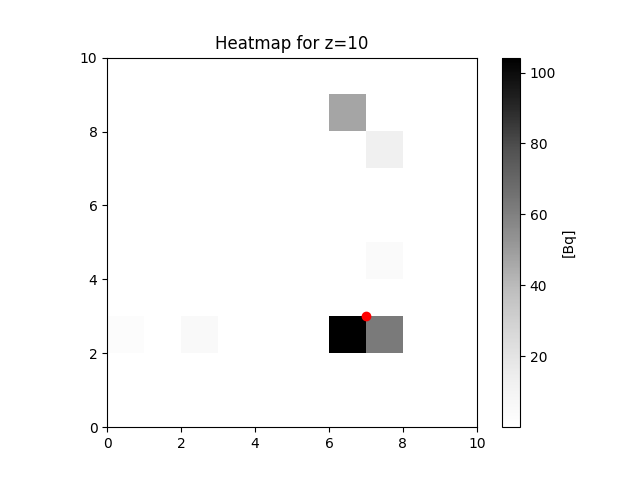

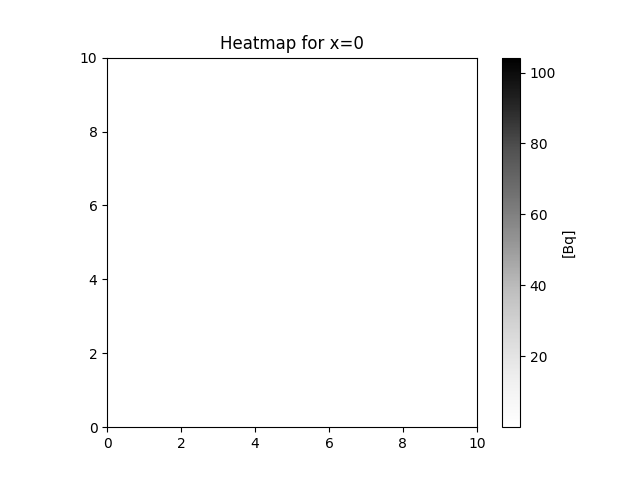

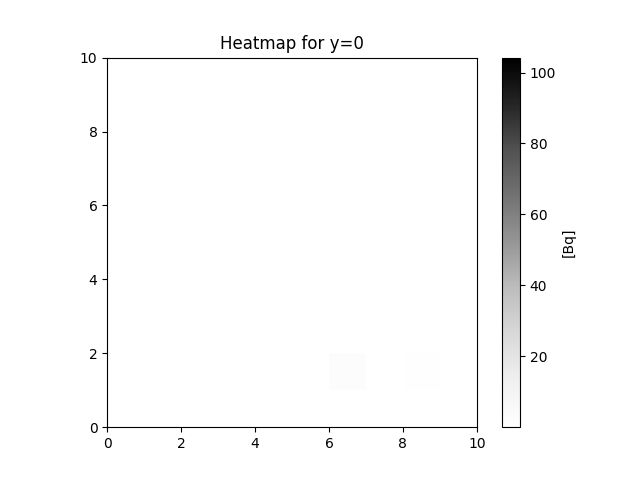

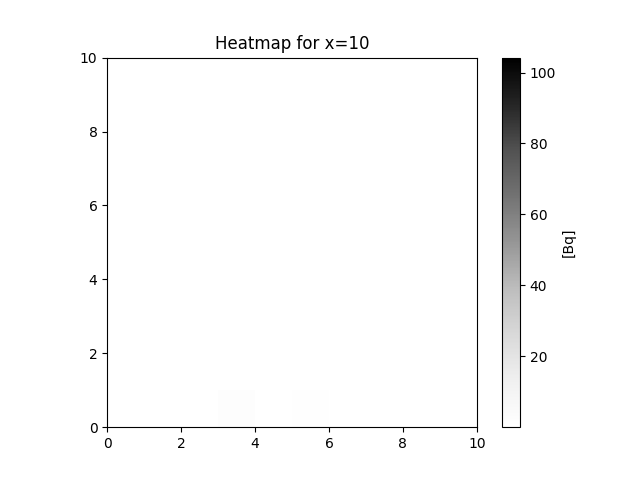

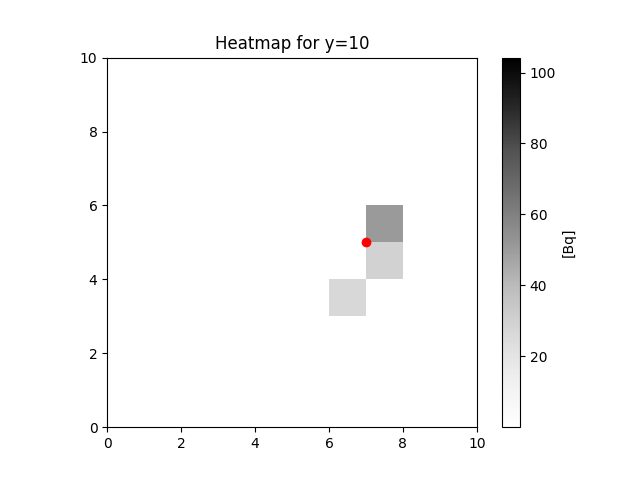

In [22]:
# 地面 z=0
plot_heatmap(restored_qs[0].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=0', sources=[(source[0], source[1]) for source in source_list if source[2] == 0], vmin=vmin, vmax=vmax)

# 天井 z=10
plot_heatmap(restored_qs[1].reshape((x, y)), (x, y), [0, x, 0, y], 'Heatmap for z=10', sources=[(source[0], source[1]) for source in source_list if source[2] == 10], vmin=vmin, vmax=vmax)

# 側面1 x=0
plot_heatmap(restored_qs[2].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=0', sources=[(source[1], source[2]) for source in source_list if source[0] == 0], vmin=vmin, vmax=vmax)

# 側面2 y=0
plot_heatmap(restored_qs[3].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=0', sources=[(source[0], source[2]) for source in source_list if source[1] == 0], vmin=vmin, vmax=vmax)

# 側面3 x=10
plot_heatmap(restored_qs[4].reshape((y, z)), (y, z), [0, y, 0, z], 'Heatmap for x=10', sources=[(source[1], source[2]) for source in source_list if source[0] == 10], vmin=vmin, vmax=vmax)

# 側面4 y=10
plot_heatmap(restored_qs[5].reshape((x, z)), (x, z), [0, x, 0, z], 'Heatmap for y=10', sources=[(source[0], source[2]) for source in source_list if source[1] == 10], vmin=vmin, vmax=vmax)

In [23]:
class RadiationSource:
    def __init__(self, x, y, z, bq):
        self.x = x
        self.y = y
        self.z = z
        self.bq = bq

# クラスのインスタンスに変換
source_list = [RadiationSource(*src) for src in [source_1, source_2, source_3]]

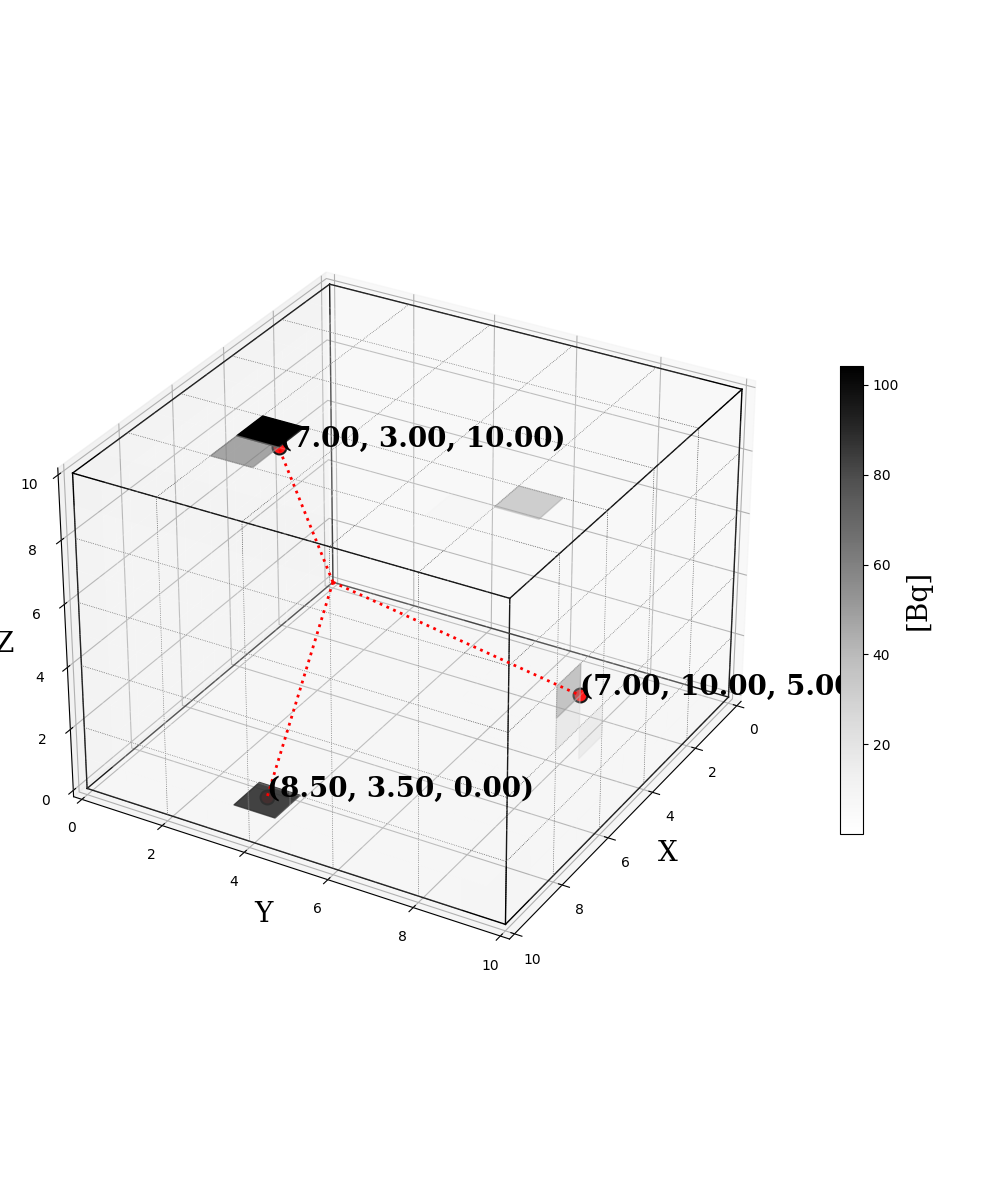

In [25]:
plot_3d_heatmap(restored_qs, x, y, z, sources=source_list, vmin=vmin, vmax=vmax)

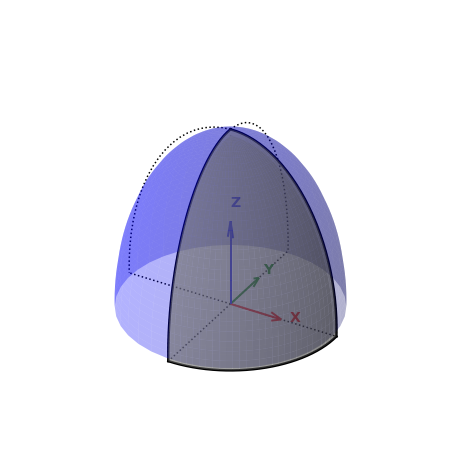

In [ ]:
# 3D図の作成（ラベルを図の右側に配置し、division lineは保持）
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 3D図の作成
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# フォント設定（Arialが使用できない環境ではデフォルトフォントを使用）
font_settings = {'fontsize': 14, 'weight': 'bold'}

# 非指向性検出器（球体）の上半分を作成（半径6）
radius_inner = 6  # 検出器の半径
radius_outer = 6.2  # 遮蔽体の外側半径（厚さ0.2）

u = np.linspace(0, np.pi/2, 40)  # 上半分のみ
v = np.linspace(0, 2 * np.pi, 40)
u, v = np.meshgrid(u, v)

x_sphere = radius_inner * np.sin(u) * np.cos(v)
y_sphere = radius_inner * np.sin(u) * np.sin(v)
z_sphere = radius_inner * np.cos(u)

# 非指向性検出器（青色）の上半分
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='blue', alpha=0.3, edgecolor='none')

# 遮蔽体（手前の1/4部分に移動）
theta = np.linspace(0, np.pi/2, 30)
phi = np.linspace(-np.pi/2, 0, 30)  # 遮蔽体を手前に配置（前方の1/4）
theta, phi = np.meshgrid(theta, phi)

x_outer = radius_outer * np.sin(theta) * np.cos(phi)
y_outer = radius_outer * np.sin(theta) * np.sin(phi)
z_outer = radius_outer * np.cos(theta)

x_inner = radius_inner * np.sin(theta) * np.cos(phi)
y_inner = radius_inner * np.sin(theta) * np.sin(phi)
z_inner = radius_inner * np.cos(theta)

# 遮蔽体の外側（半透明グレー、線なし）
ax.plot_surface(x_outer, y_outer, z_outer, color='gray', alpha=0.6, edgecolor='none')

# 遮蔽体の内側（半透明グレー、線なし）
ax.plot_surface(x_inner, y_inner, z_inner, color='gray', alpha=0.2, edgecolor='none')

# 遮蔽体の輪郭線（全て太くする）
ax.plot(x_outer[:, -1], y_outer[:, -1], z_outer[:, -1], color='black', linewidth=2.5)  # 縦の輪郭
ax.plot(x_outer[-1, :], y_outer[-1, :], z_outer[-1, :], color='black', linewidth=2.5)  # 横の輪郭
ax.plot(x_outer[:, 0], y_outer[:, 0], z_outer[:, 0], color='black', linewidth=2.5)  # 左側の輪郭
ax.plot(x_outer[0, :], y_outer[0, :], z_outer[0, :], color='black', linewidth=2.5)  # 上側の輪郭

# 1/4分割線（黒の点線）
t = np.linspace(0, np.pi/2, 20)
x_line = radius_outer * np.sin(t)
y_line = np.zeros_like(t)
z_line = radius_outer * np.cos(t)

# XZ平面の分割線
ax.plot(x_line, y_line, z_line, color='black', linestyle='dotted', linewidth=1.5)
ax.plot(y_line, x_line, z_line, color='black', linestyle='dotted', linewidth=1.5)

# XY平面の分割線
ax.plot(x_line, y_line, np.zeros_like(z_line), color='black', linestyle='dotted', linewidth=1.5)
ax.plot(y_line, x_line, np.zeros_like(z_line), color='black', linestyle='dotted', linewidth=1.5)

# 遮蔽体がない部分にも線を追加（下半分）
ax.plot(-x_line, y_line, z_line, color='black', linestyle='dotted', linewidth=1.5)
ax.plot(y_line, -x_line, z_line, color='black', linestyle='dotted', linewidth=1.5)
ax.plot(-x_line, y_line, np.zeros_like(z_line), color='black', linestyle='dotted', linewidth=1.5)
ax.plot(y_line, -x_line, np.zeros_like(z_line), color='black', linestyle='dotted', linewidth=1.5)

# XYZ軸の簡易表示（矢印とラベル）
ax.quiver(0, 0, 0, 3, 0, 0, color='red', linewidth=2, arrow_length_ratio=0.2)
ax.text(3.5, 0, 0, "X", color="red", **font_settings)

ax.quiver(0, 0, 0, 0, 3, 0, color='green', linewidth=2, arrow_length_ratio=0.2)
ax.text(0, 3.5, 0, "Y", color="green", **font_settings)

ax.quiver(0, 0, 0, 0, 0, 3, color='blue', linewidth=2, arrow_length_ratio=0.2)
ax.text(0, 0, 3.5, "Z", color="blue", **font_settings)

# 座標軸と枠を完全に非表示
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_frame_on(False)
ax.axis('off')

# タイトル削除
ax.set_title("")

# 図の表示
plt.show()

